# 05. Benchmarking: Lululemon vs ALO Yoga

Comparativa de la percepcion de marca entre Lululemon y ALO Yoga a partir de reviews de Trustpilot.

**Dimensiones:**
1. Rating general
2. Sentimiento del texto
3. Temas recurrentes
4. Diferencias por mercado (pais)

In [1]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
from plotting import setup_style, save_fig, COLORS
setup_style()

tp = pd.read_csv("../../datos/clean/trustpilot_all_sentiment.csv", parse_dates=["published_date"])
lulu = tp[tp["brand"] == "Lululemon"].copy()
alo = tp[tp["brand"] == "ALO Yoga"].copy()

print(f"Lululemon: {len(lulu)} reviews | ALO Yoga: {len(alo)} reviews")

Lululemon: 188 reviews | ALO Yoga: 195 reviews


## 1. Comparativa de ratings

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/bench_ratings_comparativa.png


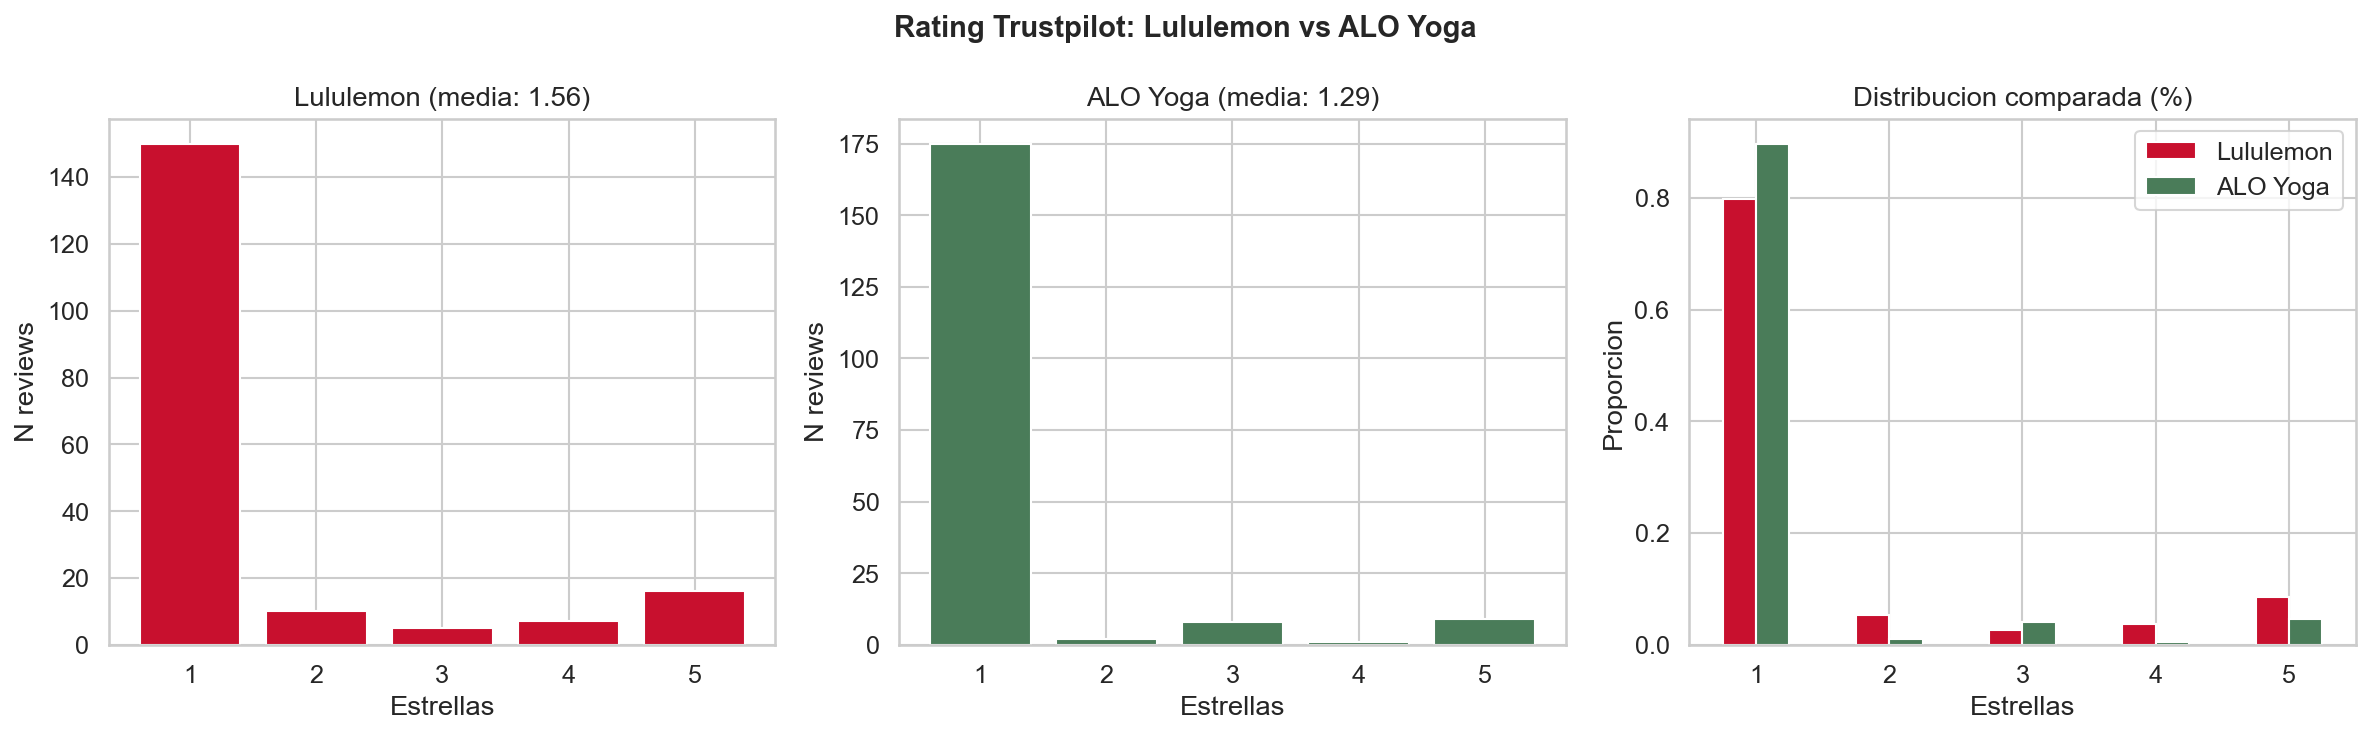

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (brand, df, color) in zip(axes[:2], [("Lululemon", lulu, COLORS["lululemon_red"]),
                                               ("ALO Yoga", alo, COLORS["alo_green"])]):
    rating_dist = df["rating"].value_counts().sort_index()
    ax.bar(rating_dist.index, rating_dist.values, color=color, edgecolor="white")
    ax.set_title(f"{brand} (media: {df['rating'].mean():.2f})")
    ax.set_xlabel("Estrellas")
    ax.set_ylabel("N reviews")
    ax.set_xticks([1, 2, 3, 4, 5])

ratings_comp = pd.DataFrame({
    "Lululemon": lulu["rating"].value_counts(normalize=True).sort_index(),
    "ALO Yoga": alo["rating"].value_counts(normalize=True).sort_index(),
})
ratings_comp.plot(kind="bar", ax=axes[2], color=[COLORS["lululemon_red"], COLORS["alo_green"]])
axes[2].set_title("Distribucion comparada (%)")
axes[2].set_xlabel("Estrellas")
axes[2].set_ylabel("Proporcion")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Rating Trustpilot: Lululemon vs ALO Yoga", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "bench_ratings_comparativa")
plt.show()

## 2. Sentimiento del texto

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/bench_sentimiento_comparativa.png


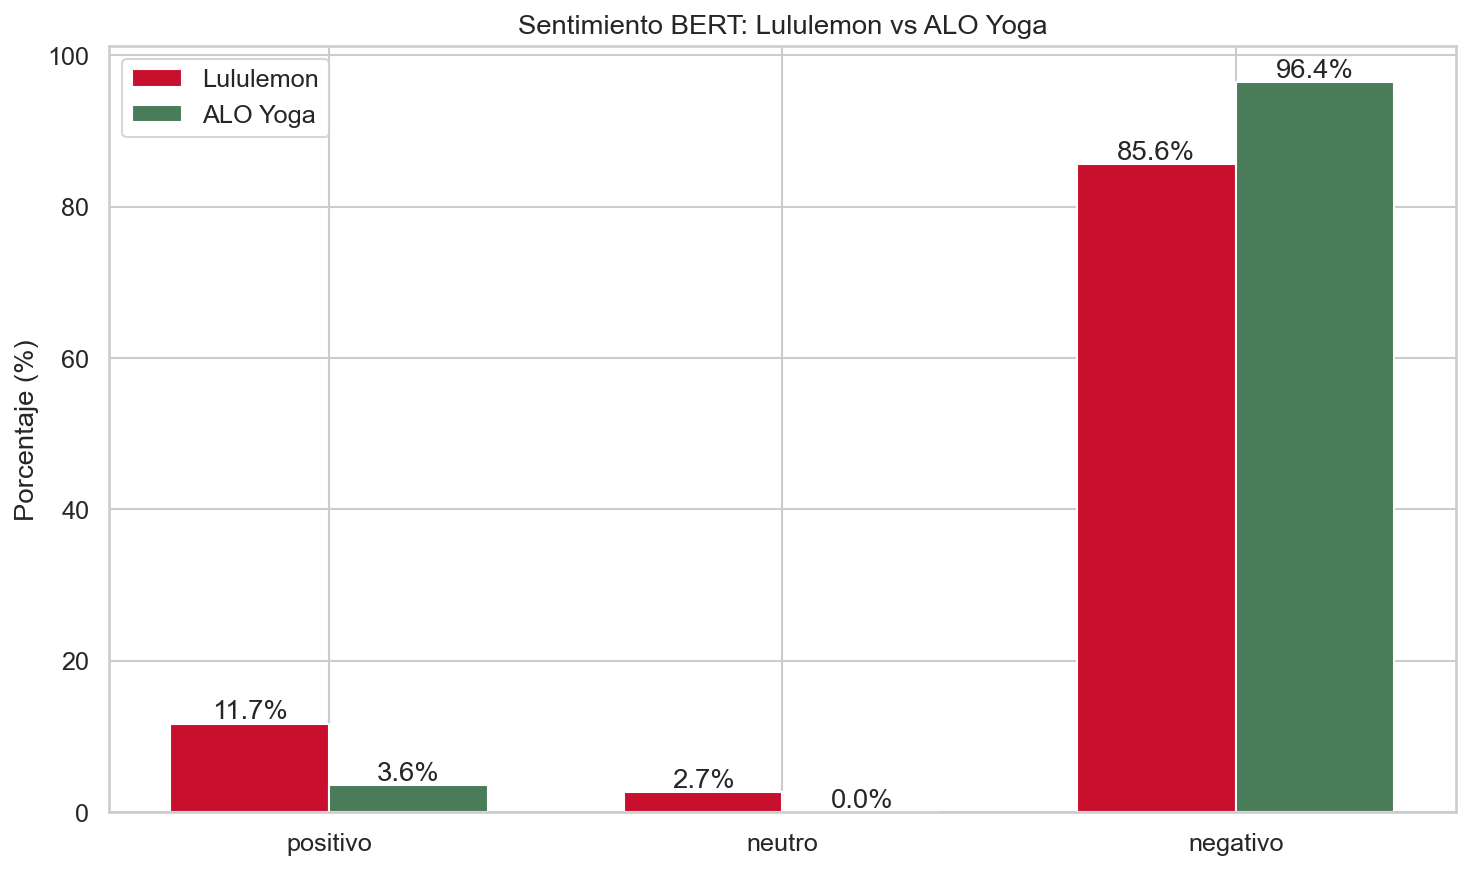

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

sent_order = ["positivo", "neutro", "negativo"]
x = np.arange(len(sent_order))
width = 0.35

lulu_pcts = lulu["sentiment_label"].value_counts(normalize=True).reindex(sent_order, fill_value=0)
alo_pcts = alo["sentiment_label"].value_counts(normalize=True).reindex(sent_order, fill_value=0)

bars1 = ax.bar(x - width/2, lulu_pcts.values * 100, width, label="Lululemon", color=COLORS["lululemon_red"])
bars2 = ax.bar(x + width/2, alo_pcts.values * 100, width, label="ALO Yoga", color=COLORS["alo_green"])

ax.set_xticks(x)
ax.set_xticklabels(sent_order)
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Sentimiento BERT: Lululemon vs ALO Yoga")
ax.legend()
ax.bar_label(bars1, fmt="%.1f%%")
ax.bar_label(bars2, fmt="%.1f%%")

plt.tight_layout()
save_fig(fig, "bench_sentimiento_comparativa")
plt.show()

## 3. Temas recurrentes por marca

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/bench_wordclouds_marca.png


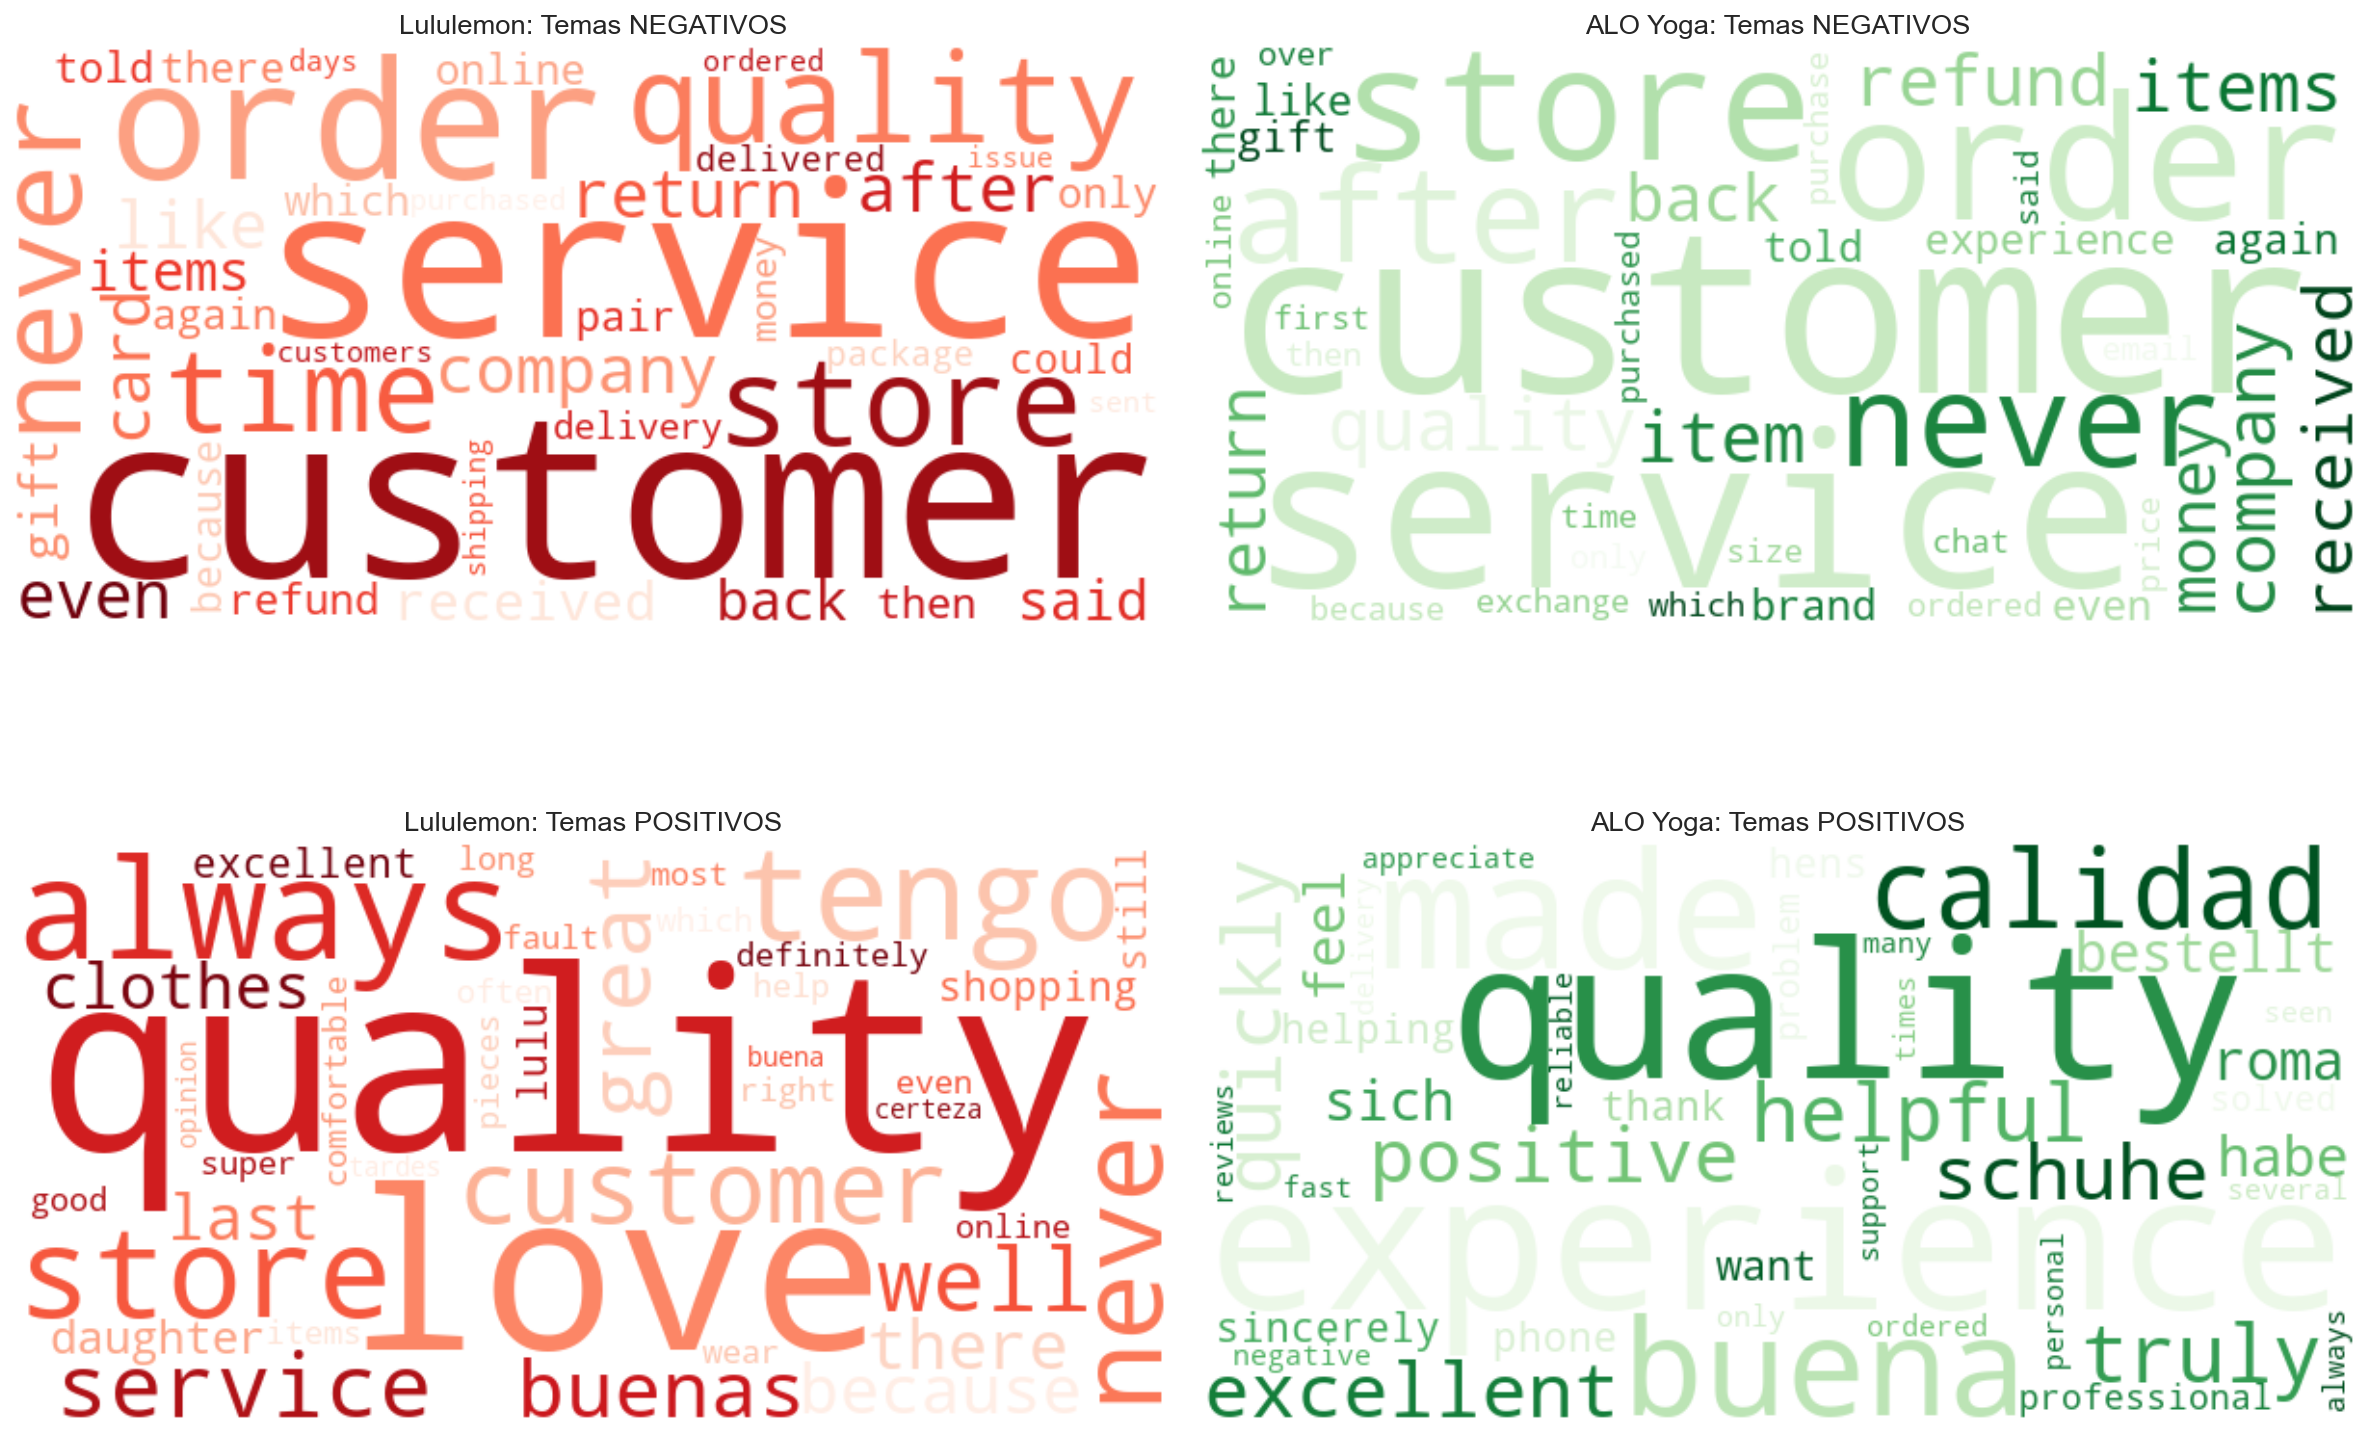

In [4]:
def get_top_words(texts, n=40, min_len=4):
    stopwords = {"this", "that", "with", "have", "from", "they", "them", "their", "your", "would",
                 "been", "were", "will", "just", "more", "como", "para", "pero", "este", "esta",
                 "very", "much", "also", "about", "what", "when", "than", "some", "lululemon", "yoga"}
    words = []
    for text in texts:
        if pd.isna(text):
            continue
        tokens = re.findall(r'\b[a-zA-Z\u00e1\u00e9\u00ed\u00f3\u00fa\u00f1\u00fc]+\b', str(text).lower())
        words.extend([w for w in tokens if len(w) >= min_len and w not in stopwords])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, (brand, df, cmap) in enumerate([("Lululemon", lulu, "Reds"), ("ALO Yoga", alo, "Greens")]):
    neg_words = dict(get_top_words(df[df["sentiment_label"]=="negativo"]["text_clean"]))
    if neg_words:
        wc = WordCloud(width=600, height=300, background_color="white", colormap=cmap).generate_from_frequencies(neg_words)
        axes[0, col].imshow(wc, interpolation="bilinear")
    axes[0, col].axis("off")
    axes[0, col].set_title(f"{brand}: Temas NEGATIVOS")

    pos_words = dict(get_top_words(df[df["sentiment_label"]=="positivo"]["text_clean"]))
    if pos_words:
        wc = WordCloud(width=600, height=300, background_color="white", colormap=cmap).generate_from_frequencies(pos_words)
        axes[1, col].imshow(wc, interpolation="bilinear")
    axes[1, col].axis("off")
    axes[1, col].set_title(f"{brand}: Temas POSITIVOS")

plt.tight_layout()
save_fig(fig, "bench_wordclouds_marca")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/bench_evolucion_rating.png


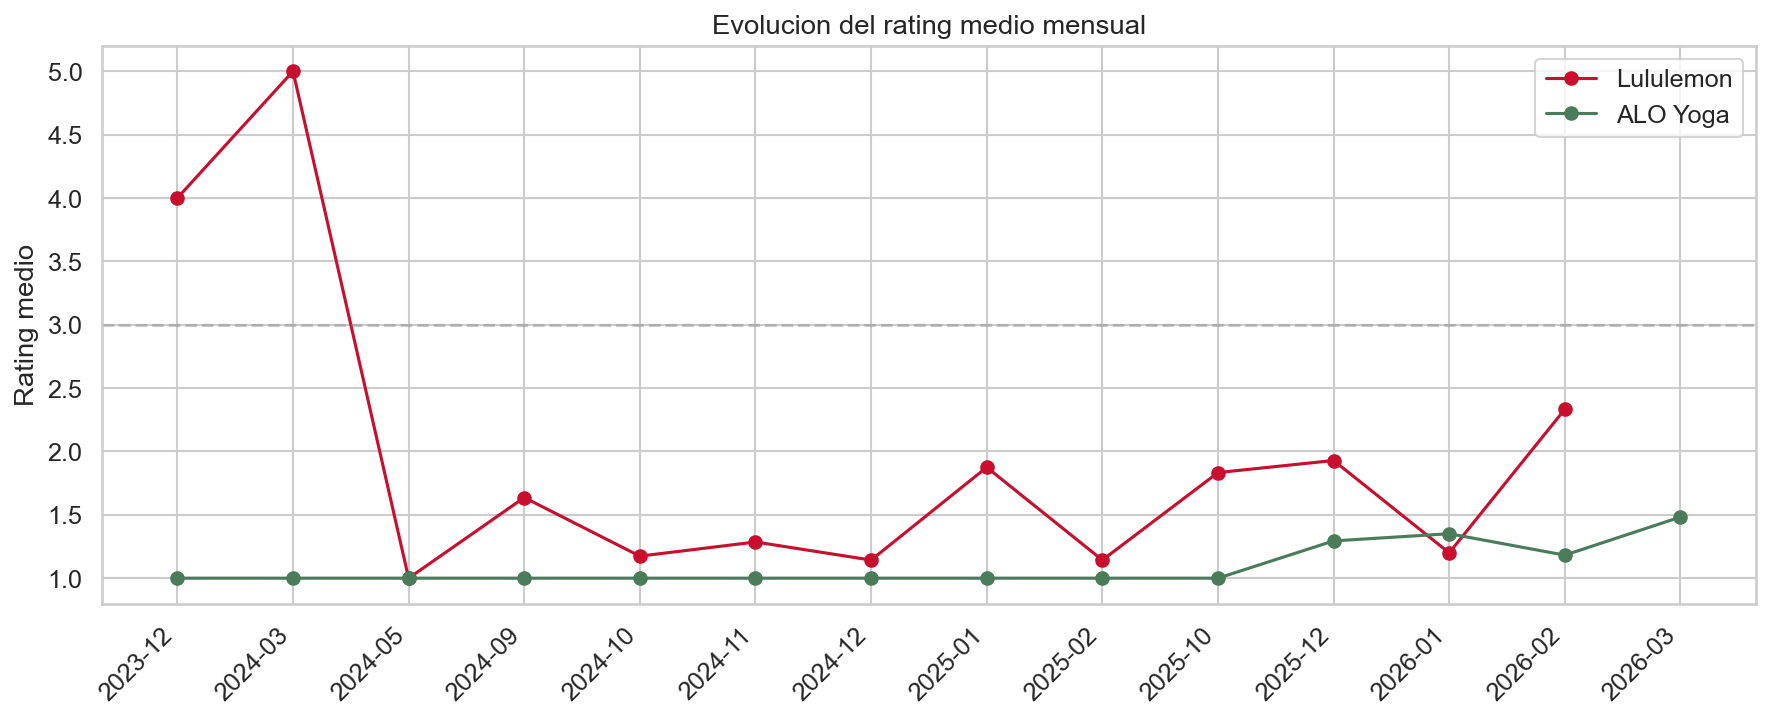

In [5]:
# Rating medio mensual
fig, ax = plt.subplots(figsize=(12, 5))

for brand, color in [("Lululemon", COLORS["lululemon_red"]), ("ALO Yoga", COLORS["alo_green"])]:
    sub = tp[tp["brand"] == brand].copy()
    monthly = sub.groupby(sub["published_date"].dt.to_period("M"))["rating"].mean()
    monthly.index = monthly.index.astype(str)
    ax.plot(range(len(monthly)), monthly.values, marker="o", label=brand, color=color)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels(monthly.index, rotation=45, ha="right")

ax.set_title("Evolucion del rating medio mensual")
ax.set_ylabel("Rating medio")
ax.legend()
ax.axhline(3, color="gray", linestyle="--", alpha=0.4)
plt.tight_layout()
save_fig(fig, "bench_evolucion_rating")
plt.show()

In [6]:
bench_resumen = pd.DataFrame({
    "Metrica": ["N reviews", "Rating medio", "% Positivo (BERT)", "% Negativo (BERT)",
                 "Sent. medio (estrellas)", "Reviews verificadas (%)"],
    "Lululemon": [
        len(lulu), f"{lulu['rating'].mean():.2f}",
        f"{(lulu['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(lulu['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{lulu['sentiment_stars'].mean():.2f}",
        f"{lulu['is_verified'].mean()*100:.1f}%",
    ],
    "ALO Yoga": [
        len(alo), f"{alo['rating'].mean():.2f}",
        f"{(alo['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(alo['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{alo['sentiment_stars'].mean():.2f}",
        f"{alo['is_verified'].mean()*100:.1f}%",
    ],
})
bench_resumen.to_csv("../../outputs/tablas/bench_resumen.csv", index=False)
bench_resumen

,Metrica,Lululemon,ALO Yoga
0,N reviews,188,195
1,Rating medio,1.56,1.29
2,% Positivo (BERT),11.7%,3.6%
3,% Negativo (BERT),85.6%,96.4%
4,Sent. medio (estrellas),1.60,1.23
5,Reviews verificadas (%),0.0%,0.0%
